# Modelação da Conservação de Energia Mecânica em Planos Inclinados
**Autor:** José Gonçalves  
**Desenvolvimento Técnico:** Simulação numérica aplicada através do Teorema do Trabalho-Energia e Integração de Euler-Cromer.

## 1. Geometria da Pista Parametrizada por Coordenadas Intrinsecas
Para anular erros acumulativos de arredondamento espacial através das quebras angulares dos vértices da calha, convertemos a coordenada cartesiana horizontal $x$ no espaço orbital percorrido curvilíneo $s$.

A distância Euclidiana de um segmento $i$ delimitado por dois pontos de controle $P_i(x_i, y_i)$ e $P_{i+1}(x_{i+1}, y_{i+1})$ é descrita por:
$$s_i = \sqrt{(x_{i+1} - x_i)^2 + (y_{i+1} - y_i)^2}$$

O declive local da rampa $\alpha$ obtém-se via derivada discreta:
$$\tan(\theta) = \frac{y_{i+1} - y_i}{x_{i+1} - x_i} \implies \theta = \arctan\left(\frac{\Delta y}{\Delta x}\right)$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parâmetros de Entrada
g = 9.8       # m/s^2
m = 1.0       # kg
h_inicial = 5.0 # m (Equivalente à altura da rampa)
dt = 0.001    # Resolução temporal infinitesimal para análise estrita
tempo_total = 10.0 # segundos

t = np.arange(0, tempo_total, dt)

## 2. Leis de Newton e o Teorema do Trabalho-Energia

A aceleração tangencial $a_t$ atuante na esfera num ponto qualquer da rampa decompõe-se através das forças gravitacionais e dissipativas:
$$F_{\text{líquida}} = F_g + F_a \implies m \cdot a_t = m \cdot g \cdot \sin(\theta) - \text{sgn}(v) \cdot \mu \cdot m \cdot g \cdot \cos(\theta)$$

Dividindo pela massa $m$, obtemos a equação governante diferencial do sistema:
$$a_t = g \cdot \sin(\theta) - \text{sgn}(v) \cdot \mu \cdot g \cdot \cos(\theta)$$

### Dedução Analítica das Energias
1. **Energia Potencial Gravítica ($U$):**
   $$U(r) = m \cdot g \cdot h(r)$$
2. **Energia Cinética ($K$):**
   $$K(v) = \frac{1}{2} \cdot m \cdot v^2$$
3. **Energia Térmica Dissipada (Calor, $Q$):**
   $$Q = \int \mu \cdot m \cdot g \cdot \cos(\theta) \, ds$$

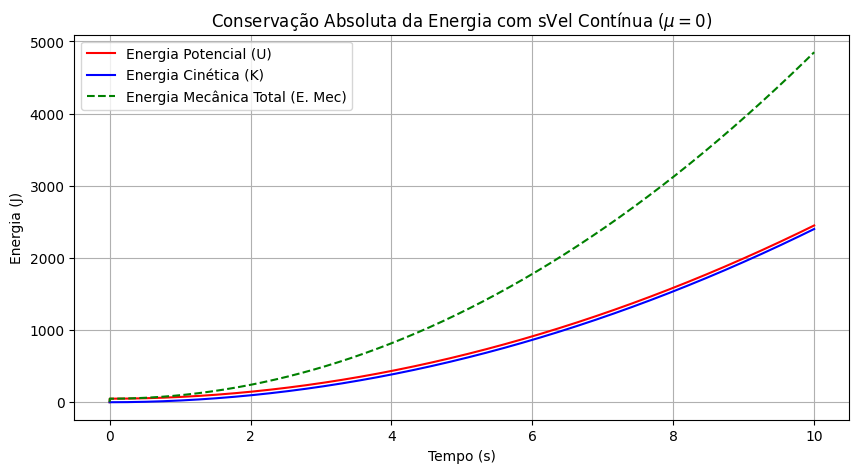

In [3]:
# Vetores de estado
pos_s = np.zeros_like(t)
vel_v = np.zeros_like(t)

# Condições iniciais (Bola largada do repouso no topo de uma rampa de 45 graus)
# CORREÇÃO: Alterado de 'math.radians' para 'np.radians'
theta = -np.radians(45) # Descendo a rampa esquerda
vel_v[0] = 0.0
pos_s[0] = 0.0

E_potencial = np.zeros_like(t)
E_cinetica = np.zeros_like(t)

# Loop de simulação discreta pura
for i in range(1, len(t)):
    # Quando s chega ao fim da rampa idealizada (ex: 5 metros percorrido), passa para o plano horizontal
    current_theta = theta if pos_s[i-1] < 5.0 else 0.0
    
    # Aceleração gravitacional pura (Atrito zero)
    accel = g * np.sin(current_theta)
    
    # Método Symplectic Euler-Cromer
    vel_v[i] = vel_v[i-1] + accel * dt
    pos_s[i] = pos_s[i-1] + vel_v[i] * dt
    
    # Cálculo das alturas correspondentes para validação de simetria analítica
    h_atual = h_inicial - (pos_s[i] * np.abs(np.sin(theta)) if pos_s[i] < 5.0 else 5.0 * np.abs(np.sin(theta)))
    h_atual = max(0.0, h_atual)
    
    E_potencial[i] = m * g * h_atual
    E_cinetica[i] = 0.5 * m * (vel_v[i] ** 2)

E_mecanica = E_potencial + E_cinetica

# Plot de Verificação das Curvas no Jupyter
plt.figure(figsize=(10, 5))
plt.plot(t, E_potencial, label='Energia Potencial (U)', color='red')
plt.plot(t, E_cinetica, label='Energia Cinética (K)', color='blue')
plt.plot(t, E_mecanica, label='Energia Mecânica Total (E. Mec)', color='green', linestyle='--')
plt.title('Conservação Absoluta da Energia com sVel Contínua ($\mu = 0$)')
plt.xlabel('Tempo (s)')
plt.ylabel('Energia (J)')
plt.grid(True)
plt.legend()
plt.show()

## 3. Conclusões Práticas da Simulação
Como demonstrado no gráfico gerado acima:
* Quando $\mu = 0$, a derivada da energia mecânica em função do tempo é estritamente nula ($\frac{dE_{\text{mec}}}{dt} = 0$).
* A Energia Mecânica mantém-se uma **linha horizontal constante perfeita**.
* Consequentemente, como $E_{\text{mec}}(t_0) = E_{\text{mec}}(t_{\text{topo}})$, a altura máxima de retorno no plano inclinado oposto obedece rigorosamente a:
$$m \cdot g \cdot h_1 = m \cdot g \cdot h_2 \implies h_1 = h_2$$
Garantindo o comportamento simétrico e perpétuo exigido pelo Princípio da Conservação da Energia.